<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EARTHSC 2245: Lecture 12 - Type 1 and 2 Errors, Single Factor Analysis of Variance
**Introductory Data Analysis for Earth and Environmental Sciences (Chapters 9 and 10)**

## 1. Type 1 Errors (False Positives)
* A Type 1 error is a False Positive, where we decide the null hypothesis is false when in reality it is not.
* For example, if we perform a Z-test drawing points from a distribution with a known mean and standard deviation, 5% of the sample means will lie outside the 95% confidence interval.
* This means 5% of the time, we will incorrectly reject the true null hypothesis of no difference between our sample mean and the population mean.
* Even when an experimental treatment has no actual effect, random sample means can naturally fall into the shaded tails of the distribution outside the 95% confidence interval by chance.

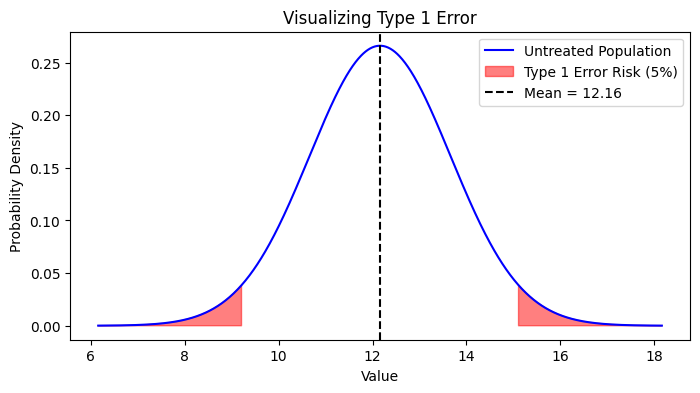

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Simulating a population distribution to demonstrate Type 1 Error (False Positive)
# Assume a known mean of 12.16, as discussed in the lecture
mu = 12.16
sigma = 1.5
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='Untreated Population', color='blue')
plt.fill_between(x, y, where=(x < mu - 1.96*sigma) | (x > mu + 1.96*sigma), color='red', alpha=0.5, label='Type 1 Error Risk (5%)')
plt.axvline(mu, color='black', linestyle='--', label=f'Mean = {mu}')
plt.title('Visualizing Type 1 Error')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

## 2. Type 2 Errors (False Negatives) and Effect Size
* A Type 2 error (or false negative) occurs when you fail to reject the null hypothesis even though it is actually false.
* The probability of making a Type 2 error is symbolized by $\beta$.
* This happens when a real effect exists, but the statistical test did not detect it.
* **Example:** In analyzing $Al_2O_3$ content in granulite xenoliths, metasomatism might increase the mean from 12.16 to 13.16 wt%.
* If the sample size is too small, there is a high degree of overlap between the original and "treated" distributions, making it likely you will miss the difference.
* **Effect Size:** This is the actual change caused by a specific treatment (e.g., an average increase of 1.0 wt% $Al_2O_3$).

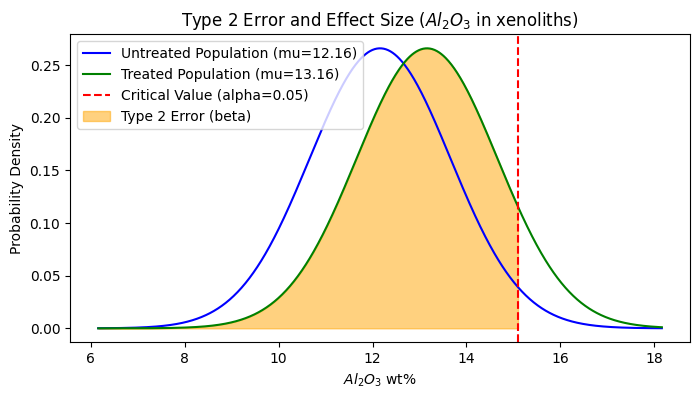

In [6]:
# Visualizing Effect Size and Type 2 Error
mu_treated = 13.16 # Metasomatized mean
y_treated = stats.norm.pdf(x, mu_treated, sigma)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='Untreated Population (mu=12.16)', color='blue')
plt.plot(x, y_treated, label='Treated Population (mu=13.16)', color='green')

# The critical value based on the untreated distribution
critical_value = mu + 1.96*sigma
plt.axvline(critical_value, color='red', linestyle='--', label='Critical Value (alpha=0.05)')

# Type 2 Error area (failing to reject H0 when treated is true)
plt.fill_between(x, y_treated, where=(x < critical_value), color='orange', alpha=0.5, label='Type 2 Error (beta)')

plt.title('Type 2 Error and Effect Size ($Al_2O_3$ in xenoliths)')
plt.xlabel('$Al_2O_3$ wt%')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

## 3. The Power of a Test
* The power of a test is the probability of correctly rejecting the null hypothesis when it is false.
* Power is calculated as $1 - \beta$, and a power of 80% (meaning a 20% risk of a Type 2 error) is generally considered desirable.
* The choice of $\alpha$ (typically 0.05) and $\beta$ (typically 0.20) should be based on the real-world consequences of being wrong.
* For example, testing for dangerous side effects of a new chemical or lead leakage into a river might mean a 20% risk of a Type 2 error (failing to see the harm) is unacceptably high.

### Factors Influencing Power
* **Effect Size:** As the difference between the means increases, the power of the test also increases.
* **Population Variance:** Smaller variance leads to less overlap between distributions, which directly increases power.
* **Sample Size ($n$):** Increasing the number of replicates reduces the standard error of the mean (SEM), narrows the 95% confidence interval, and increases power.
* **$\alpha$ Level:** Decreasing the significance level (e.g., from 0.05 to 0.01) makes it harder to commit a Type 1 error but severely weakens the test's power to detect a real effect by increasing $\beta$.

## 4. Single-factor Analysis of Variance (ANOVA)
* ANOVA is used to analyze univariate data from three or more samples, such as from different localities or experimental groups.
* **The Core Hypothesis:** Tests if the means of the populations from which the samples are drawn are not significantly different from one another.
* **Avoid Multiple t-tests:** Performing multiple two-sample t-tests to compare every pair of means is problematic because each additional t-test increases the cumulative risk of making a Type 1 error (false positive).
* Analysis of Variance (ANOVA) was developed by British statistician Sir Ronald A. Fisher in the 1910s and 1920s.

### Core Logic of ANOVA
* ANOVA takes the total variation in the dataset and divides it into two distinct components:
    * **Between-Groups (Treatment Effect):** Measures how much the group means deviate from the Grand Mean (the average of every single data point).
    * **Within-Groups (Error/Residual):** Measures how much individual observations within a specific group deviate from their own group mean (considered uncontrollable "noise").
* The fundamental formula representing the principle of additivity is: `Value = Treatment + Error`.
* Total Sum of Squares = Treatment SS + Error SS.


### Mathematical Framework and the F-Ratio
* We divide the Sum of Squares (SS) by degrees of freedom to obtain the Mean Squares (MS), which represents the "Average Variance".
* The F-ratio is found by dividing the among-group variance by the within-group variance.
* If the treatment had a large effect, $MS_{between}$ will be large, and if the noise is low, $MS_{within}$ will be small, both leading to a large F-value.
* A large F-value pushes the statistic into the "Rejection Region" of the F-distribution.

In [3]:
import pandas as pd
from scipy.stats import f_oneway

# Simulating the arithmetic example of magnesium content (MgO wt%) in tourmalines
# from three Maine localities (e.g., Mount Mica)
data = {
    'Locality_A': [3.5, 3.7, 3.6, 3.8],
    'Locality_B': [4.1, 4.0, 4.3, 4.2],
    'Mount_Mica': [6.5, 6.8, 6.6, 6.7] # Distinctly higher values
}
df = pd.DataFrame(data)

print("Magnesium Content (MgO wt%) Data:")
print(df)

# Performing Single-Factor ANOVA
f_stat, p_value = f_oneway(df['Locality_A'], df['Locality_B'], df['Mount_Mica'])

print(f"\nF-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. At least one locality mean is significantly different.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

Magnesium Content (MgO wt%) Data:
   Locality_A  Locality_B  Mount_Mica
0         3.5         4.1         6.5
1         3.7         4.0         6.8
2         3.6         4.3         6.6
3         3.8         4.2         6.7

F-statistic: 620.00
P-value: 2.2885e-10
Conclusion: Reject the null hypothesis. At least one locality mean is significantly different.


## 5. Interpreting Results, Post-hoc Tests, and Assumptions
* **Omnibus Nature:** The ANOVA is an Omnibus Test; a significant F-ratio indicates that at least one treatment mean is likely different, but it lacks specificity and does not tell you which specific groups are different.
* Further statistical testing using "multiple comparison" (post-hoc) tests is required to find specific differences.
    * **Tukey’s HSD:** The gold standard, great for equal group sizes.
    * **Bonferroni Correction:** Very conservative; divides alpha by the number of comparisons.
    * **Scheffé’s Test:** Flexible but least powerful.
* **Effect Size ($\eta^2$):** Tells you the proportion of total variance explained by the factor (0.01 is small, 0.06 is medium, 0.14+ is large).

### ANOVA Assumptions
If these pillars are weak, your p-value becomes unreliable:
* **Independence:** Each data point must be independent.
* **Normality:** Residuals should follow a normal distribution (checked via Shapiro-Wilk or Q-Q plot).
* **Homogeneity of Variance:** The spread in each group must be roughly equal (checked via Levene’s Test). If unequal, Welch’s ANOVA should be used.
* **Random Sampling:** Data should be collected randomly to ensure generalizability.

### Fixed vs. Random Effects
* **Model I (Fixed Effects):** Used when the researcher is interested in specific, chosen treatments (e.g., three specific lakes).
* **Model II (Random Effects):** Used when treatments are a random sample from a much larger population (e.g., three lakes chosen at random from 21).

In [4]:
from scipy.stats import levene
# Note: Ensure you have statsmodels installed (`pip install statsmodels`)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Checking Homogeneity of Variance using Levene's Test
stat, p_levene = levene(df['Locality_A'], df['Locality_B'], df['Mount_Mica'])
print(f"Levene's Test P-value: {p_levene:.4f}")
if p_levene > 0.05:
    print("Variances are roughly equal (Assumption met).")
else:
    print("Variances are unequal (Assumption violated - consider Welch's ANOVA).")

# 2. Post-hoc Analysis using Tukey's HSD
# Reshape data for the test
values = df.values.flatten(order='F')
groups = ['Locality_A']*4 + ['Locality_B']*4 + ['Mount_Mica']*4

tukey_results = pairwise_tukeyhsd(endog=values, groups=groups, alpha=0.05)
print("\n--- Tukey HSD Post-hoc Test Results ---")
print(tukey_results)

Levene's Test P-value: 1.0000
Variances are roughly equal (Assumption met).

--- Tukey HSD Post-hoc Test Results ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
Locality_A Locality_B      0.5 0.001 0.2451 0.7549   True
Locality_A Mount_Mica      3.0   0.0 2.7451 3.2549   True
Locality_B Mount_Mica      2.5   0.0 2.2451 2.7549   True
---------------------------------------------------------
